In [34]:
# pip install -i https://test.pypi.org/simple/ orbitlab

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from orbitlab.units import ureg, G
from orbitlab.physics import orbital_velocity, escape_velocity, gravitational_force
from orbitlab.simulation import simulate_orbit, simulate_orbit_python
from orbitlab.visualization import plot_orbit

### Units and Constants
Before doing physics, we must define our environment. OrbitLab uses ``` Pint``` to prevent unit errors (like adding meters to kilometers). We use a central UnitRegistry to define physical quantities.

In [ ]:
print(f"Using G = {G}")

# Earth constants
M_earth = 5.972e24 * ureg.kg
R_earth = 6371 * ureg.km

# Let's pick a satellite altitude (International Space Station height)
altitude = 400 * ureg.km
orbit_radius = R_earth + altitude

print(f"Target Orbit Radius: {orbit_radius.to(ureg.km)}")

Using G = 6.6743e-11 meter ** 3 / kilogram / second ** 2
Target Orbit Radius: 6771 kilometer


###  Basic Orbital Mechanics
The first set of functions in orbitlab.physics calculates fundamental velocities.Circular Orbital Velocity: The speed needed to stay in a circular orbit at a specific distance $r$.$$v_c = \sqrt{\frac{GM}{r}}$$Escape Velocity: The speed needed to break free from a planet's gravitational pull.$$v_e = \sqrt{\frac{2GM}{r}}$$

In [36]:
v_circ = orbital_velocity(M_earth, orbit_radius)
v_esc = escape_velocity(M_earth, orbit_radius)

print(f"Circular Velocity: {v_circ.to('km/s'):.2f}")
print(f"Escape Velocity: {v_esc.to('km/s'):.2f}")

# Check the force on a 1000kg satellite
force = gravitational_force(M_earth, 1000 * ureg.kg, orbit_radius)
print(f"Gravitational Force: {force.to('newton'):.2f}")

Circular Velocity: 7.67 kilometer / second
Escape Velocity: 10.85 kilometer / second
Gravitational Force: 8694.01 newton


### The Simulation Kernel (Numba Accelerated)
The core of OrbitLab is the ```simulate_orbit``` function. It uses Euler Integration to solve the equations of motion over time. Because calculating thousands of time-steps in pure Python is slow, we use Numba to compile the math into machine code.

In [71]:
# Initial vectors (Start at [R, 0] moving at [0, V])
initial_pos = np.array([orbit_radius.to('m').magnitude, 0.0]) * ureg.m
initial_vel = np.array([0.0, v_circ.to('m/s').magnitude]) * (ureg.m / ureg.s)

dt = 0.01 * ureg.s  
total_steps = 100

print(f"Simulating for {total_steps * dt}...")

x, y = simulate_orbit(
    M_earth, 
    initial_pos, 
    initial_vel, 
    dt, 
    total_steps
)

Simulating for 1.0 second...


### Visualization
Data isn't helpful unless we can see the path. We use ```matplotlib``` to render the trajectory.

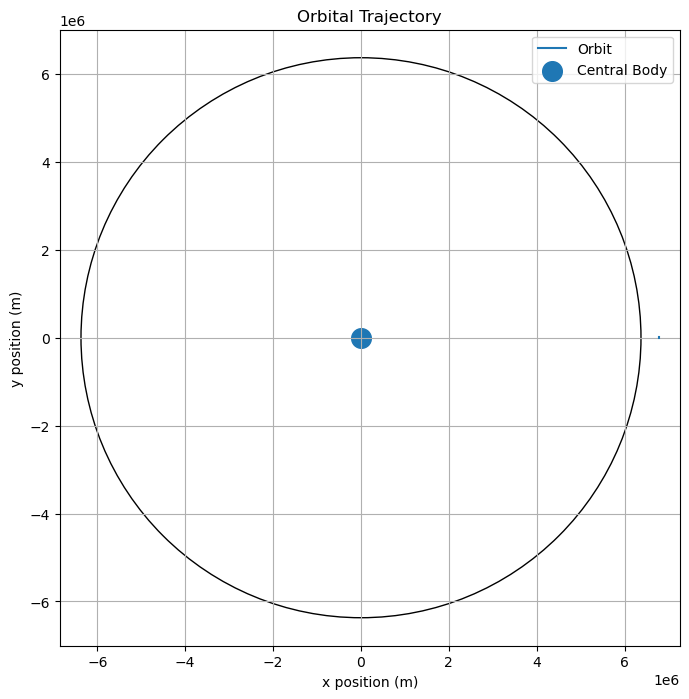

In [72]:
plot_orbit(x, y, central_body_radius=R_earth.to('m').magnitude)

### Performance Benchmarking
Let's compare the speed. Since Numba compiles on the first "lazy" call, the second run will show the true speed.

In [ ]:
import time

pos_raw = initial_pos.to('m').magnitude.astype(float)
vel_raw = initial_vel.to('m/s').magnitude.astype(float)
G_raw = G.to('m^3/kg/s^2').magnitude
M_raw = M_earth.to('kg').magnitude
dt_raw = 1.0
bench_steps = 100_000

# Benchmark Python
start = time.time()
simulate_orbit_python(pos_raw.copy(), vel_raw.copy(), G_raw, M_raw, dt_raw, bench_steps)
py_time = time.time() - start

# Benchmark Numba (Run once to compile, then measure)
from orbitlab.simulation import _simulate_orbit_numba
_simulate_orbit_numba(pos_raw.copy(), vel_raw.copy(), G_raw, M_raw, dt_raw, 1) # Warm up

start = time.time()
_simulate_orbit_numba(pos_raw.copy(), vel_raw.copy(), G_raw, M_raw, dt_raw, bench_steps)
nb_time = time.time() - start

print(f"Results for {bench_steps:,} steps:")
print(f"Pure Python: {py_time:.4f}s")
print(f"Numba JIT:   {nb_time:.4f}s")
print(f"Speedup:     {py_time/nb_time:.1f}x")

Results for 100,000 steps:
Pure Python: 0.7095s
Numba JIT:   0.0151s
Speedup:     46.9x
